In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from PIL import Image
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

from metrics import get_metrics_batch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
    else "cpu"
)

In [2]:
import os
import pandas as pd

data_dir = "test_images-2"
files = [f for f in os.listdir(data_dir) if f.endswith(".png")]

def extract_patient_id(filename):
    return filename.split("_")[0]

data = pd.DataFrame({
    "filename": files
})

data["patient_id"] = data["filename"].apply(extract_patient_id)

# print(data.head())

len(data['patient_id'].unique()), len(files)

(13, 702)

In [3]:
data['patient_id'].nunique()

13

In [4]:
data

,filename,patient_id
0,78ecae88188b8c0562bbc36522389517_T1_rep03_to_a...,78ecae88188b8c0562bbc36522389517
1,652416ea8681149657802ed52ee2462e_T1_rep01_to_a...,652416ea8681149657802ed52ee2462e
2,380f13f1f0191090d679a793954c35eb_T1_rep01_to_a...,380f13f1f0191090d679a793954c35eb
3,6316870ae76209fc363705651b133f26_T1_rep01_to_a...,6316870ae76209fc363705651b133f26
4,74258d592c969d920cc6d617416fee4a_T1_rep02_to_a...,74258d592c969d920cc6d617416fee4a
...,...,...
697,c882e37acb80eee7d07a9d60a0b1f22e_T1_rep01_to_a...,c882e37acb80eee7d07a9d60a0b1f22e
698,380f13f1f0191090d679a793954c35eb_T1_rep01_to_a...,380f13f1f0191090d679a793954c35eb
699,74258d592c969d920cc6d617416fee4a_T1_rep01_to_a...,74258d592c969d920cc6d617416fee4a
700,3dcc06f44453d4e8c3263cc4b089e5b1_T1_rep03_to_a...,3dcc06f44453d4e8c3263cc4b089e5b1


In [5]:
# gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
# train_idx, test_idx = next(gss.split(data, groups=data['patient_id']))

# train_df = data.iloc[train_idx].reset_index(drop=True)
# train_df
gkf = GroupKFold(n_splits=5)
gkf

GroupKFold(n_splits=5, random_state=None, shuffle=False)

In [6]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

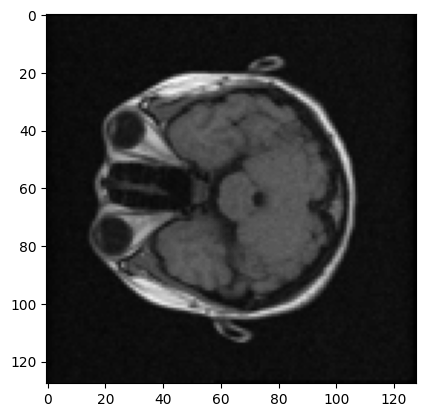

In [33]:
data_dir = "train_images-2"
files = [f for f in os.listdir(data_dir) if f.endswith(".png")]

def extract_patient_id(filename):
    return filename.split("_")[0]

df = pd.DataFrame({"filename": files})
df["patient_id"] = df["filename"].apply(extract_patient_id)

# for i in range(50, 100):
#     plt.imshow(Image.open(os.path.join(data_dir, files[i])), cmap='gray')
#     plt.title(files[i])
#     plt.show()

#resize the image to 256x25
def resize_image(img, size=(128, 128)):
    img = img.resize(size)
    return img

resized = resize_image(Image.open(os.path.join(data_dir, files[10])))
plt.imshow(resized, cmap='gray')
# normalize the images
# def normalize_image(img):
#     img = np.array(img).astype(np.float32)
#     img = (img - img.min()) / (img.max() - img.min())
#     return img

# # show normalized image
# normalized_img = normalize_image(Image.open(os.path.join(data_dir, files[3000])))
# plt.imshow(normalized_img)


In [35]:
# Load + resize + convert to grayscale
img = Image.open(os.path.join(data_dir, files[10])).convert('L')
resized = resize_image(img)

# Convert to tensor [0,1]
clean = transforms.ToTensor()(resized)   # shape: [1,128,128]

# Gaussian noise (sigma = 0.01)
sigma = 0.04
noise = torch.randn_like(clean) * sigma
noisy = torch.clamp(clean + noise, 0., 1.)

# Convert to numpy
clean_np = clean.squeeze().numpy()
noisy_np = noisy.squeeze().numpy()


psnr = psnr_metric(clean_np, noisy_np, data_range=1.0)
#SSIM
ssim = ssim_metric(clean_np, noisy_np, data_range=1.0)

print(f"PSNR ($\sigma$=0.04): {psnr:.2f} dB")
print(f"SSIM ($\sigma$=0.04): {ssim}" )

PSNR ($\sigma$=0.04): 28.92 dB
SSIM ($\sigma$=0.04): 0.6000465371777889


In [36]:
# Load + resize + convert to grayscale
img = Image.open(os.path.join(data_dir, files[10])).convert('L')
resized = resize_image(img)

# Convert to tensor [0,1]
clean = transforms.ToTensor()(resized)   # shape: [1,128,128]

# Add Gaussian noise (sigma = 0.01)
sigma = 0.06
noise = torch.randn_like(clean) * sigma
noisy = torch.clamp(clean + noise, 0., 1.)

# Convert to numpy
clean_np = clean.squeeze().numpy()
noisy_np = noisy.squeeze().numpy()

# Compute PSNR
psnr = psnr_metric(clean_np, noisy_np, data_range=1.0)

#SSIM
ssim = ssim_metric(clean_np, noisy_np, data_range=1.0)

print(f"PSNR (sigma=0.04): {psnr:.2f} dB")
print(f"SSIM (sigma=0.04): {ssim}" )

PSNR (sigma=0.04): 25.83 dB
SSIM (sigma=0.04): 0.45646378624402395


In [32]:
# Load + resize + convert to grayscale
img = Image.open(os.path.join(data_dir, files[10])).convert('L')
resized = resize_image(img)

# Convert to tensor [0,1]
clean = transforms.ToTensor()(resized)   # shape: [1,128,128]

# Add Gaussian noise (sigma = 0.01)
sigma = 0.1
noise = torch.randn_like(clean) * sigma
noisy = torch.clamp(clean + noise, 0., 1.)

# Convert to numpy
clean_np = clean.squeeze().numpy()
noisy_np = noisy.squeeze().numpy()

# Compute PSNR
psnr = psnr_metric(clean_np, noisy_np, data_range=1.0)

#SSIM
ssim = ssim_metric(clean_np, noisy_np, data_range=1.0)

print(f"PSNR (σ=0.04): {psnr:.2f} dB")
print(f"SSIM (σ=0.04): {ssim}" )

PSNR (σ=0.04): 21.72 dB
SSIM (σ=0.04): 0.2798916257300854


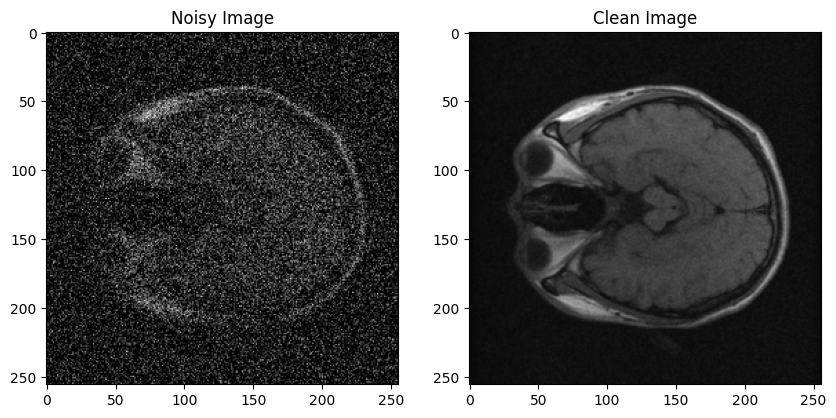

In [56]:
class MedicalDenoiseDataset(Dataset):
    def __init__(self, file_list, root_dir, noise_std=0.2):
        self.files = file_list
        self.root = root_dir
        self.noise_std = noise_std
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root, self.files[idx])
        img = Image.open(path)
        clean = self.transform(img)

        noise = torch.randn_like(clean) * self.noise_std
        noisy = torch.clamp(clean + noise, 0., 1.)

        return noisy, clean

## example clean and noisy image
clean_noisy = MedicalDenoiseDataset(df['filename'].tolist(), data_dir)
noisy_img, clean_img = clean_noisy[200]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.imshow(noisy_img.squeeze(), cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Clean Image")
plt.imshow(clean_img.squeeze(), cmap='gray')

In [137]:
## Split the dataset into train and test using in 80-10 ratio based on patient_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)

train_idx, test_idx = next(gss.split(data, groups=df['patient_id']))

train_df = data.iloc[train_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)


## separately held out test set for evaluation
# test_dir = "test_images-2"
# os.makedirs(test_dir, exist_ok=True)
# for filename in test_df['filename']:
#     src_path = os.path.join(data_dir, filename)
#     dst_path = os.path.join(test_dir, filename)
#     os.rename(src_path, dst_path)
    
    
train_dir = "train_images-2"
os.makedirs(train_dir, exist_ok=True)
for filename in train_df['filename']:
    src_path = os.path.join(data_dir, filename)
    dst_path = os.path.join(train_dir, filename)
    os.rename(src_path, dst_path)

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Train set size: 6210
Test set size: 702


In [140]:
len(data['patient_id'].unique()), len(train_df['patient_id'].unique()), len(test_df['patient_id'].unique())

(128, 115, 13)

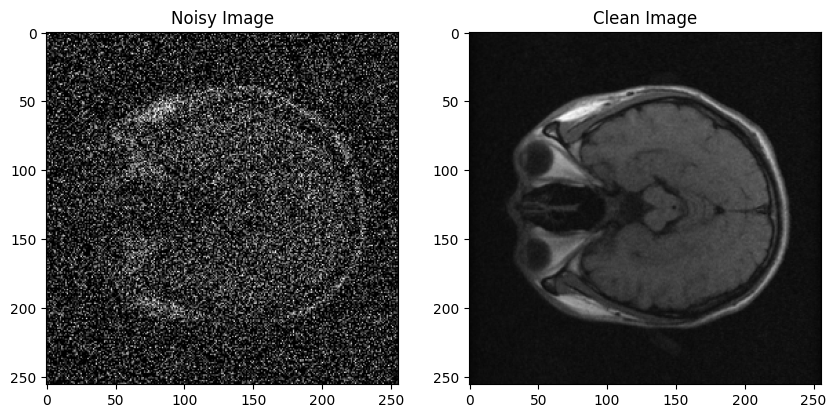

In [157]:
## example clean and noisy image
clean_noisy = MedicalDenoiseDataset(df['filename'].tolist(), data_dir)
noisy_img, clean_img = clean_noisy[200]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.imshow(noisy_img.squeeze(), cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Clean Image")
plt.imshow(clean_img.squeeze(), cmap='gray')

In [138]:
## UNet
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.final(d1))

In [37]:
NUM_EPOCHS = 20
BATCH_SIZE = 8
LR = 1e-4
PATIENCE = 5  # early stopping patience

gkf = GroupKFold(n_splits=5)

all_psnr = []
all_ssim = []
best_overall_loss = float("inf")
best_overall_model_path = None

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, groups=train_df["patient_id"])):

    print(f"\n Fold {fold+1}")

    train_files = train_df.iloc[train_idx]["filename"].values
    val_files = train_df.iloc[val_idx]["filename"].values

    train_dataset = MedicalDenoiseDataset(train_files, data_dir)
    val_dataset = MedicalDenoiseDataset(val_files, data_dir)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.L1Loss()

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0
    best_model_path = f"best_model_fold_{fold+1}.pth"

    # TRAINING 

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0

        for noisy, clean in train_loader:
            noisy, clean = noisy.to(device), clean.to(device)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # VALIDATION 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for noisy, clean in val_loader:
                noisy, clean = noisy.to(device), clean.to(device)
                output = model(noisy)
                loss = criterion(output, clean)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: "
              f"Train={train_loss:.4f} | Val={val_loss:.4f}")

        # BEST MODEL 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("  → Best model saved.")
        else:
            early_stop_counter += 1

        # EARLY STOPPING 
        if early_stop_counter >= PATIENCE:
            print("  → Early stopping triggered.")
            break
        
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    psnr_list = []
    ssim_list = []

    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            output = model(noisy)

            output_np = output.cpu().numpy()
            clean_np = clean.cpu().numpy()

            for i in range(output_np.shape[0]):
                psnr = peak_signal_noise_ratio(
                    clean_np[i, 0], output_np[i, 0], data_range=1)
                ssim_val = structural_similarity(
                    clean_np[i, 0], output_np[i, 0], data_range=1)

                psnr_list.append(psnr)
                ssim_list.append(ssim_val)

    fold_psnr = np.mean(psnr_list)
    fold_ssim = np.mean(ssim_list)

    print(f"Fold {fold+1} PSNR: {fold_psnr:.2f}")
    print(f"Fold {fold+1} SSIM: {fold_ssim:.4f}")

    all_psnr.append(fold_psnr)
    all_ssim.append(fold_ssim)

    # Track best overall model
    if best_val_loss < best_overall_loss:
        best_overall_loss = best_val_loss
        best_overall_model_path = best_model_path

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("L1 Loss")
    plt.title(f"Fold {fold+1} Loss Curve")
    plt.legend()
    plt.show()
    
print("\n CROSS-VALIDATION RESULTS")
print(f"Average PSNR: {np.mean(all_psnr):.2f}")
print(f"Average SSIM: {np.mean(all_ssim):.4f}")
print(f"Best overall model: {best_overall_model_path}")

NameError: name 'train_df' is not defined